In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_LOSS,FOLD_VL_LOSS,FOLD_TR_LOSS
from cross_common import MEE,MSE,RMSE,MAE,LOSS


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [22]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

default_batch_size = 64
default_epochs = 1000

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3)


# ---- The metrics to calculate in train ---
epochs_metrics_dict = {
    LOSS: (nnc.MEELoss, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
}
the_metrics = epochs_metrics_dict.keys()
# ------------------------------------------


# ----- Defining model basic architecture --------
base_hidden_layers = ["32"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ------------ Learning rate ---------------
base_weight_decay = [0]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


dict_keys(['loss', 'mse', 'mae', 'rmse'])


In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = trial_dict["batch_size"]
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict["metrics"]
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.MLP(net_trial, output_adapter_trial)

    #init_method = "kaiming" if activation_trial == "relu" else "xavier"
    #init_nonlinearity = "relu" if activation_trial == "relu" else "tanh"
    model_trial.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "metrics": metrics_trial
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_LOSS,
    fold_metric=FOLD_VL_LOSS,
    early_epoch=30
)

coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]

<h5>Coarse Grained</h5>

In [7]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": coarse_learning_rates,
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-03-28 17:53:59,674] A new study created in memory with name: no-name-fadd6b01-0f82-42af-905c-5db8681b6408
  5%|▌         | 1/20 [00:01<00:31,  1.63s/it]

[I 2026-03-28 17:54:01,317] Trial 0 finished with values: [25.1949834042239, 0.11815749261424226, 0.20797810600855793] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 10%|█         | 2/20 [00:02<00:26,  1.47s/it]

[I 2026-03-28 17:54:02,669] Trial 1 finished with values: [24.87432208312463, 0.17732311535844048, 0.2591906606755306] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:04<00:23,  1.41s/it]

...

[I 2026-03-28 17:54:24,405] Trial 17 finished with values: [25.606376640702, 0.05356909005616684, 0.11418923352595695] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:26<00:01,  1.37s/it]

[I 2026-03-28 17:54:25,787] Trial 18 finished with values: [24.84037234656289, 0.18003456322595976, 0.2707477698320145] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


100%|██████████| 20/20 [00:27<00:00,  1.38s/it]

[I 2026-03-28 17:54:27,189] Trial 19 finished with values: [25.224218731074668, 0.12044175902405757, 0.2191074291369347] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


In [8]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.003


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor


objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": (low_lr, high_lr),
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-03-28 17:54:27,229] A new study created in memory with name: no-name-03554f15-a756-4111-a3a1-df64da94105c
  3%|▎         | 1/30 [00:01<00:40,  1.38s/it]

[I 2026-03-28 17:54:28,611] Trial 0 finished with values: [25.357084220304802, 0.12575756556508846, 0.23469513931926908] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.001139245203070755, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:02<00:38,  1.38s/it]

[I 2026-03-28 17:54:29,983] Trial 1 finished with values: [24.378641406824055, 0.21561396211784944, 0.25824148594077917] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0028718639820979395, 'weight_decay': 0}.


 10%|█         | 3/30 [00:04<00:37,  1.38s/it]

...

[I 2026-03-28 17:55:06,562] Trial 27 finished with values: [23.68564549271737, 0.366921873401212, 0.27687836613066996] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008455354896193274, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [00:40<00:01,  1.39s/it]

[I 2026-03-28 17:55:07,944] Trial 28 finished with values: [23.90075115659515, 0.28675579726582395, 0.2608879967847238] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.005085059530098912, 'weight_decay': 0}.


100%|██████████| 30/30 [00:42<00:00,  1.41s/it]

[I 2026-03-28 17:55:09,384] Trial 29 finished with values: [23.830608200041315, 0.32370452772852565, 0.26905782855836796] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.006434667386159881, 'weight_decay': 0}.


In [10]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
print(coarse_grained_lr, final_lr)

0.003 0.0010389954997613209


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [11]:

evaluate_wd_partial = partial(
    nnc.evaluate_wd,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [12]:
coarse_grained_wd_trials_nr = 20

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": coarse_weight_decays,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-03-28 17:55:09,409] A new study created in memory with name: no-name-bf194b91-cdcc-46f0-bf53-ff2b7ca4e9a8
  5%|▌         | 1/20 [00:01<00:26,  1.40s/it]

[I 2026-03-28 17:55:10,810] Trial 0 finished with values: [25.438002954115216, 0.20988444750815916] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 0.0}.


 10%|█         | 2/20 [00:02<00:25,  1.41s/it]

[I 2026-03-28 17:55:12,226] Trial 1 finished with values: [25.18090073482054, 0.23496061853633066] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 0.0005}.


 15%|█▌        | 3/20 [00:04<00:23,  1.41s/it]

...

[I 2026-03-28 17:55:34,701] Trial 17 finished with values: [25.29130032041718, 0.22841943330008974] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 0.0}.


 95%|█████████▌| 19/20 [00:26<00:01,  1.40s/it]

[I 2026-03-28 17:55:36,091] Trial 18 finished with values: [25.296179678700227, 0.24639164455927087] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 0.0001}.


100%|██████████| 20/20 [00:28<00:00,  1.40s/it]

[I 2026-03-28 17:55:37,507] Trial 19 finished with values: [25.38119249770678, 0.22292925158202337] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 0.0}.


In [13]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

0.0001


<h5>Fine Grained</h5>

In [14]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))


objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": (low_wd, high_wd),
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-03-28 17:55:37,528] A new study created in memory with name: no-name-19b93bef-390e-4b44-a618-bda3ee448e53
  3%|▎         | 1/30 [00:01<00:41,  1.41s/it]

[I 2026-03-28 17:55:38,942] Trial 0 finished with values: [25.25682841071324, 0.24879972136080752] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 0.00017235496881928196}.


  7%|▋         | 2/30 [00:02<00:39,  1.41s/it]

[I 2026-03-28 17:55:40,344] Trial 1 finished with values: [25.301621524750335, 0.24653195111290316] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 7.090546905281144e-05}.


 10%|█         | 3/30 [00:04<00:37,  1.40s/it]

...

[I 2026-03-28 17:56:16,787] Trial 27 finished with values: [25.177074138402016, 0.22454738938525765] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 3.6695541503820706e-05}.


 97%|█████████▋| 29/30 [00:40<00:01,  1.41s/it]

[I 2026-03-28 17:56:18,201] Trial 28 finished with values: [25.356801471086854, 0.2234090370322157] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 9.888857489642766e-05}.


100%|██████████| 30/30 [00:42<00:00,  1.40s/it]

[I 2026-03-28 17:56:19,590] Trial 29 finished with values: [25.415255298077383, 0.22678844270180676] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 7.16026953396656e-05}.


In [15]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 0.0001 Fine grained WD: 8.181667329650258e-05


<h4>Model Capacity</h4>
<hr/>

In [16]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_LOSS,
    vl_key=FOLD_VL_LOSS
)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": cr.common_fold_strategy(n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers + ["64","128","256","128,64","256,128","32,16,8","64,32,16","128,64,32"],
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)



[I 2026-03-28 17:56:19,613] A new study created in memory with name: no-name-a252bb3a-5d64-43c5-9563-6b7ff78b70d7
  3%|▎         | 1/30 [00:02<01:14,  2.56s/it]

[I 2026-03-28 17:56:22,173] Trial 0 finished with values: [23.966329025268557, 0.5306131591796905] and parameters: {'hidden_layers': '256', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 8.181667329650258e-05}.


  7%|▋         | 2/30 [00:05<01:18,  2.81s/it]

[I 2026-03-28 17:56:25,160] Trial 1 finished with values: [22.563716445922854, 1.5780918884277355] and parameters: {'hidden_layers': '256,128', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 8.181667329650258e-05}.


 10%|█         | 3/30 [00:08<01:11,  2.67s/it]

...

[I 2026-03-28 17:57:37,855] Trial 27 finished with values: [23.878286453247068, 0.6601755371093709] and parameters: {'hidden_layers': '64,32,16', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 8.181667329650258e-05}.


 97%|█████████▋| 29/30 [01:21<00:02,  2.80s/it]

[I 2026-03-28 17:57:40,745] Trial 28 finished with values: [23.827999618530274, 0.665892120361331] and parameters: {'hidden_layers': '64,32,16', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 8.181667329650258e-05}.


100%|██████████| 30/30 [01:23<00:00,  2.79s/it]

[I 2026-03-28 17:57:43,281] Trial 29 finished with values: [24.233284835815432, 0.38503085327148767] and parameters: {'hidden_layers': '128', 'activation': 'relu', 'learning_rate': 0.0010389954997613209, 'weight_decay': 8.181667329650258e-05}.


In [17]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [256, 128] - best metrics: 22.3866639251709 - best VL/TR gap: 1.7710146484375002


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [18]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [19]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, "relu")
model_template = nnc.build_nn_model(net, output_adapter)

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=default_epochs
kv_batch_size=default_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "metrics": epochs_metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 148 (best VL loss: 24.1300)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (64)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0010389954997613209, 'weight_decay': 8.181667329650258e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 127 (best VL loss: 24.3632)
Train summary
-------------------------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

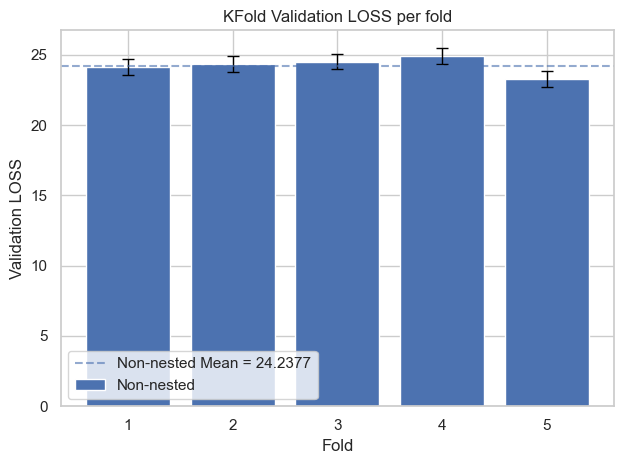

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,23.229928,24.124055,0.894128,3.85%
2,23.798921,24.354106,0.555184,2.33%
3,24.675914,24.522062,-0.153852,0.62%
4,23.958266,24.919131,0.960865,4.01%
5,23.409308,23.269165,-0.140143,0.60%
MEAN,23.814467,24.237704,0.423237,2.28%
STD,0.563216,0.614356,0.542821,1.66%


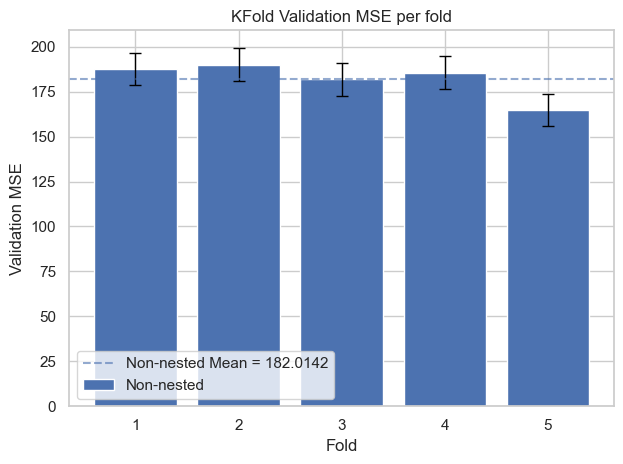

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,169.207279,187.706468,18.499189,10.93%
2,174.538384,190.111573,15.573189,8.92%
3,186.999639,181.846617,-5.153022,2.76%
4,178.832383,185.594308,6.761926,3.78%
5,174.398090,164.812158,-9.585932,5.50%
MEAN,176.795155,182.014225,5.219070,6.38%
STD,6.646364,10.083711,12.376572,3.46%


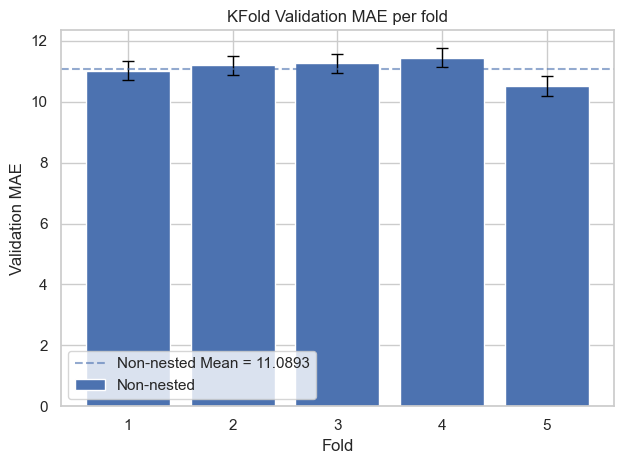

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,10.585623,11.025624,0.440001,4.16%
2,10.872643,11.198988,0.326345,3.00%
3,11.271062,11.260550,-0.010512,0.09%
4,10.966696,11.442080,0.475383,4.33%
5,10.695692,10.519076,-0.176616,1.65%
MEAN,10.878343,11.089264,0.210920,2.65%
STD,0.265101,0.351789,0.289378,1.79%


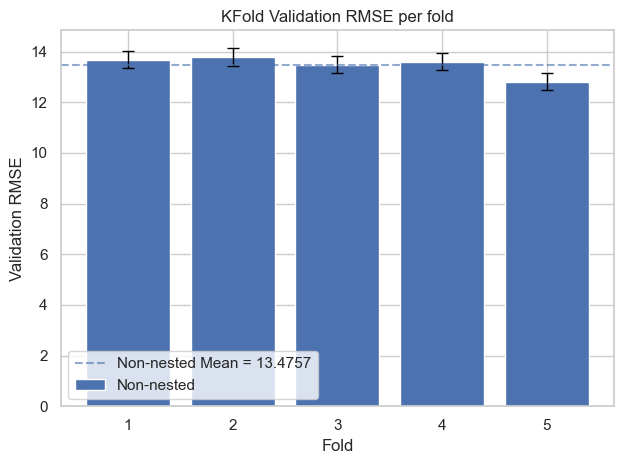

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,12.946465,13.683994,0.737528,5.70%
2,13.162423,13.787580,0.625157,4.75%
3,13.638995,13.484872,-0.154124,1.13%
4,13.303535,13.604199,0.300664,2.26%
5,13.135213,12.817902,-0.317311,2.42%
MEAN,13.237326,13.475709,0.238383,3.25%
STD,0.258050,0.384041,0.465155,1.90%


In [23]:
importlib.reload(cr)
for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_regression_table(fold_histories, use=metric))


<h4>Bootstrap Variance</h4>

In [ ]:

epochs_metrics_bootstrap_dict = {
    MEE: (cr.mee, min)
}

importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, epochs_metrics_bootstrap_dict, bootstrap_params)

In [ ]:
cr.aggregate_scores(bootstrap_scores)

In [ ]:
#cr.plot_bootstrap_distribution([metric.mee for metric in bootstrap_scores])

<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [ ]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=scaler), # 0.1 = 10%
    **inner_train_params
)

In [ ]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_mee
epochs_kf_tr_mee = train_kf_result.epochs_tr_mee
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_grad = train_kf_result.epochs_grad_norm

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

In [ ]:
importlib.reload(nnc)
importlib.reload(cr)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

In [ ]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

In [ ]:
importlib.reload(nnc)
nnc.plot_epoch_mse(epochs_kf_tr_mse, epochs_kf_vl_mse)

In [ ]:
importlib.reload(cc)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_mee)
print(f"{mean:.4f} ± {std:.4f}")

<h3>Best Hyperparameters</h3>
<hr/>

In [ ]:
#print(inner_train_params)
for key, value in inner_train_params.items():
    print(f"{key}: {value}")

print(f"hidden layers: {final_hidden_layers}")